In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _cellAssemblies(session,regs=None,when=None,window=0.025,drop_mix=False):

    # load data
    R = fma.regions.regions(session,states='sws',phases=when,events=['ripples','InfraSlowRhythm/infraslowaval'])
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]

    spikes = R.spikes(regs=regs)
    task = [s for s in list(R.phases) if 'sleep' not in s]
    weights, templates, raster = fma.analysis.cellAssembliesICA(spikes,window=window,when=R.eventIntervals(task[0]),drop_mix=drop_mix)

    # reactivations on all spikes
    reactivation, peaks = fma.analysis.reactivationStrength(raster,templates)

    # region identities
    reg_id = np.full(len(R.units(regs=regs)),'none')
    for r in regs:
        reg_id[R.units(r)] = r
    identities = [['+'+reg_id[i] if x > 0 else '-'+reg_id[i] for i, x in enumerate(w) if x != 0] for w in weights.T]

    unique_identities = []
    for i in identities:
        un, count = np.unique([r[1:] for r in i], return_counts=True)
        unique_identities.append([f'{c}{u}' for u, c in zip(un,count)])

    # events to study assembly responses
    events = isru.loadHpcPfcEvents(session)
    is_isa = {e: fma.general.restrict(events[e],R.eventIntervals('slownr'),s_ind=True)[1] for e in events}
    phases = [s for s in list(R.phases) if 'sleep' in s]
    yes_sleep = len(phases) > 1 and phases[1] != 'nsleep'


    epochs = [R.eventIntervals(p)[0,0]+np.array([0,1200]) for p in phases] # IT MUST ALSO BE JUST SLEEPP
    epoch_idx = {e: np.full_like(events[e],np.nan) for e in events}
    for e in events:
        _, s, i = fma.general.restrict(events[e],epochs,s_ind=True,i_ind=True)
        epoch_idx[e][s] = i

    return weights, reactivation, peaks, identities, unique_identities, raster, events, is_isa, epoch_idx, epochs, R.eventIntervals('slownr')

In [2]:
def _cellAssembliesPETH(session,regs=None,when=None,window=0.025,drop_mix=False):

    # load data
    R = fma.regions.regions(session,states='sws',phases=when,events=['ripples','InfraSlowRhythm/infraslowaval'])
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    spikes = R.spikes(regs=regs)

    # detect assemblies during task
    task = [s for s in list(R.phases) if 'sleep' not in s]
    weights, templates, raster = fma.analysis.cellAssembliesICA(spikes,window=window,when=R.eventIntervals(task[0]),drop_mix=drop_mix)

    # reactivations on all spikes
    reactivation, peaks = fma.analysis.reactivationStrength(raster,templates)

    # member's region identities
    reg_id = np.full(len(R.units(regs=regs)),'none')
    for r in regs:
        reg_id[R.units(r)] = r
    identities = [['+'+reg_id[i] if x > 0 else '-'+reg_id[i] for i, x in enumerate(w) if x != 0] for w in weights.T]
    unique_identities = []
    for i in identities:
        un, count = np.unique([r[1:] for r in i], return_counts=True)
        unique_identities.append([f'{c}{u}' for u, c in zip(un,count)])

    # events to study assembly responses
    events = isru.loadHpcPfcEvents(session)
    is_isa = {e: fma.general.restrict(events[e],R.eventIntervals('slownr'),s_ind=True)[1] for e in events}
    phases = [s for s in list(R.phases) if 'sleep' in s]
    yes_sleep = len(phases) > 1 and phases[1] != 'nsleep'
    epochs = [R.eventIntervals(p)[0,0]+np.array([0,1200]) for p in phases] # IT MUST ALSO BE JUST SLEEPP
    epoch_idx = {e: np.full_like(events[e],np.nan) for e in events}
    for e in events:
        _, s, i = fma.general.restrict(events[e],epochs,s_ind=True,i_ind=True)
        epoch_idx[e][s] = i

    peth = []
    statistic = {}
    for e in events:
        p, t, _ = fma.analysis.PETH(reactivation,events[e],limits=[-3.5,0.5]) # p has shape (events, time, assembly)
        peth.append(p)
        # asses responde to event
        avg = p.mean(axis=0) # (time, assembly)
        baseline_idx = t < -0.5
        mu = np.abs(avg[baseline_idx].mean(axis=0))
        std = avg[baseline_idx].std(axis=0)
        center_idx = (t > -0.05) & (t < 0.05)
        statistic[e] = (np.abs(avg[center_idx]).max(axis=0) - mu) / std
    names = np.concatenate([[e] * len(events[e]) for e in events])
    peth = xr.DataArray(np.concatenate(peth),dims=('ev','t','asmb'),coords={'ev': names, 't': t})

    return peth, statistic, weights, peaks, identities, unique_identities, events, is_isa, epoch_idx

In [3]:
regs = ['hpc','nr','pfc']

In [ ]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][55]
print(f'session: {session}')
peth, statistic, weights, peaks, identities, unique_identities, events, is_isa, epoch_idx = _cellAssembliesPETH(session,regs=regs,when='.*#0,1,2')

session: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.xml


Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available ids: []

Error removing breakpoint: Breakpoint id not found: 97ba5afe0ac532e4cf48ab4f68b1106d64005e112d5d4f7a4679fd558a93450c id: 10. Available i

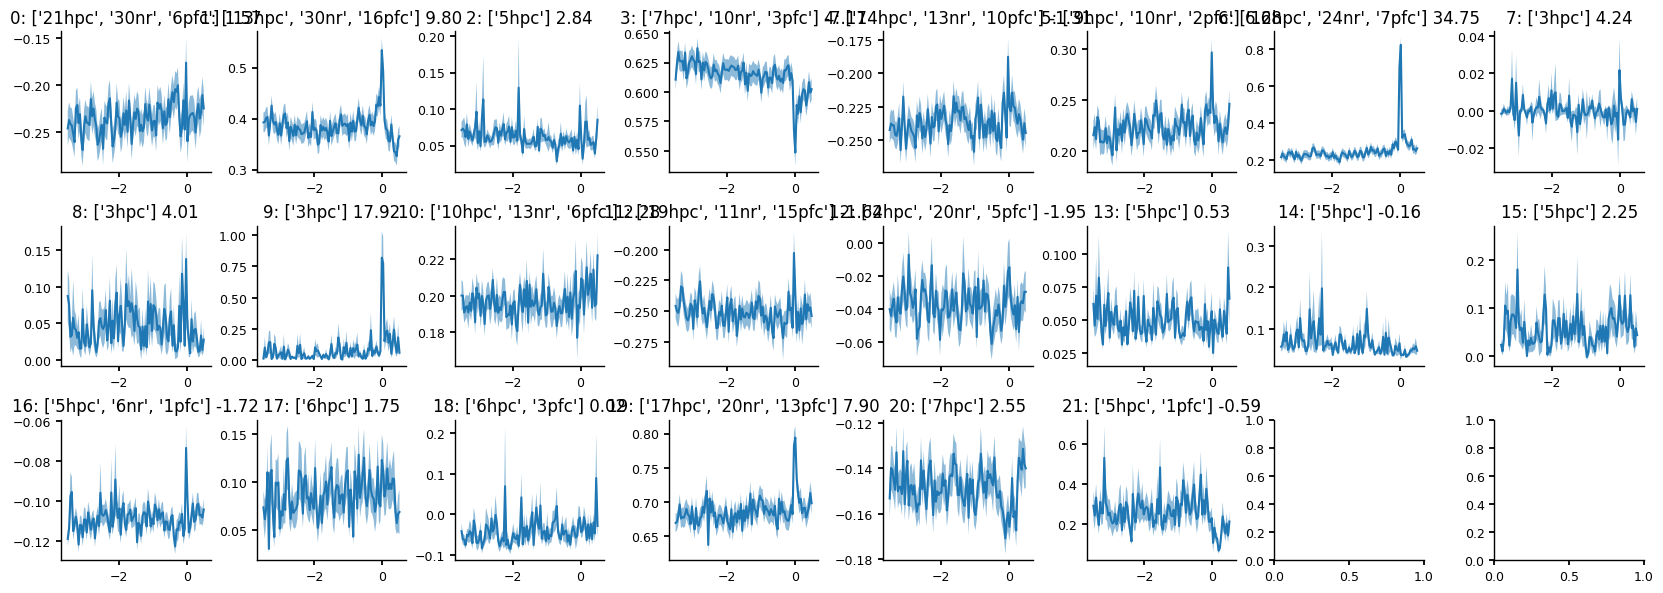

In [8]:
# peth of reactivation around events
name = 'ripples'
#n_reg = 3
#do_plot = np.where([len(i) == n_reg for i in unique_identities])[0]
fig, ax = fma.plotting.makeFigure(size=(42,15),n=(3,8))
for i in range(len(peaks)):
    j, k = np.unravel_index(i,ax.shape)

    fma.plotting.semPlot(peth.t,peth.sel(ev=name,asmb=i),ax=ax[j,k])

    ax[j,k].set_title(f"{i}: {unique_identities[i]} {statistic[name][i]:.2f}")

Q: the majority of assemblies responding to ripples contain NR units? TEST WITH: baseline avg, select asmbs which respond to ripples, for all dataset

Q: reactivations highest in post task ISA? Peaks are most likely outside ISA apparently

Q: assemblies per region reveal temporality in ripple response?

In [10]:
peth, statistic, weights, peaks, identities, unique_identities, events, is_isa, epoch_idx = fma.data.runBatch(batch_file,_cellAssembliesPETH,kwargs={'regs': regs, 'when': '.*#0,1'},sessions=[2,4,8,13,16,19,55,57])


Starting Batch, 2026-07-01 16:02:33.299304 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml, 1 out of 8

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml, 2 out of 8

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml, 3 out of 8
Error in session /mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml
array must not contain infs or NaNs
Traceback:
/media/data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 491, in runBatch
/tmp/ipykernel_1841574/1425248040.py, line 10, in _cellAssembliesPETH
/media/data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/analysis.py, line 241, in cellAssembliesICA
/home/pietro/uvEnvs/fmat/lib/python3.10/site-packages/scipy/linalg/_decomp.py, line 458, in eigh
/home/pietro/uvEnvs/fmat/lib/python3.10/site-packages/scipy/_lib/_util.py, line 537, in _asarray_validated
/home/pietro/uvEnvs/fmat/lib/python3.10/site-

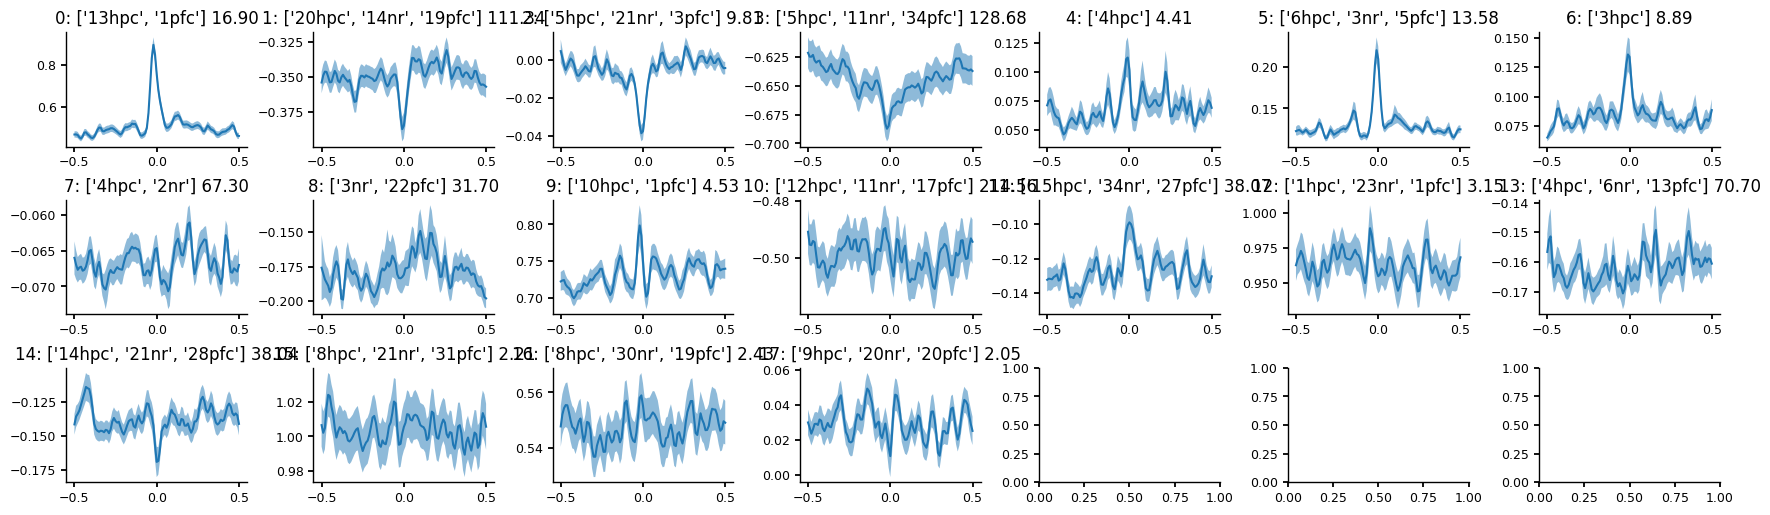

In [32]:
# peth of reactivation around events
s = 4
name = 'ripples'
#n_reg = 2
#do_plot = np.where([len(i) == n_reg for i in unique_identities[s]])[0]
fig, ax = fma.plotting.makeFigure(size=(44,13),n=(3,7))
for i in range(peth[s].shape[2]):
    j, k = np.unravel_index(i,(3,7))
    fma.plotting.semPlot(peth[s].t,peth[s].sel(ev=name,asmb=i),ax=ax[j,k])
    ax[j,k].set_title(f"{i}: {unique_identities[s][i]} {statistic[s][name][i]:.2f}")

In [4]:
for p in peaks:

    ep_p = fma.general.restrict(p[:,0],epochs[0])
    _, is_isa_p0 = fma.general.restrict(ep_p,isa,s_ind=True)
    isa_epoch0 = np.diff(fma.general.intersectIntervals((epochs[0],isa))).sum()

    ep_p = fma.general.restrict(p[:,0],epochs[1])
    _, is_isa_p1 = fma.general.restrict(ep_p,isa,s_ind=True)
    isa_epoch1 = np.diff(fma.general.intersectIntervals((epochs[1],isa))).sum()

    print(f'ISA: {is_isa_p0.sum()/isa_epoch0} nISA: {(len(is_isa_p0)-is_isa_p0.sum())/(np.diff(epochs[0])-isa_epoch0)} ISA: {is_isa_p1.sum()/isa_epoch1} nISA: {(len(is_isa_p1)-is_isa_p1.sum())/(np.diff(epochs[1])-isa_epoch1)}')

ISA: nan nISA: [0.0325] ISA: 0.28379387602069367 nISA: [0.3419767]
ISA: nan nISA: [0.9875] ISA: 0.5576300721810121 nISA: [0.42465239]
ISA: nan nISA: [0.08833333] ISA: 0.06970375902262652 nISA: [0.21921583]
ISA: nan nISA: [0.14583333] ISA: 0.3958177744499149 nISA: [0.33947138]
ISA: nan nISA: [0.40416667] ISA: 0.2364948966839114 nISA: [0.50357009]
ISA: nan nISA: [0.] ISA: 0.7742096091441731 nISA: [0.73907052]
ISA: nan nISA: [0.07083333] ISA: 0.20911127706787955 nISA: [0.16409871]
ISA: nan nISA: [0.205] ISA: 0.21657953696316098 nISA: [0.22923713]
ISA: nan nISA: [0.04166667] ISA: 0.0597460791622513 nISA: [0.08518101]
ISA: nan nISA: [0.12583333] ISA: 0.07468259895281412 nISA: [0.50858073]
ISA: nan nISA: [0.10583333] ISA: 0.07966143888300174 nISA: [0.61004635]
ISA: nan nISA: [0.1425] ISA: 0.09708737863865836 nISA: [0.28059627]
ISA: nan nISA: [0.25166667] ISA: 0.21657953696316098 nISA: [0.2893649]
ISA: nan nISA: [0.26] ISA: 0.2240477968584424 nISA: [0.41838908]
ISA: nan nISA: [0.18833333] ISA

/tmp/ipykernel_1688298/198449915.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f'ISA: {is_isa_p0.sum()/isa_epoch0} nISA: {(len(is_isa_p0)-is_isa_p0.sum())/(np.diff(epochs[0])-isa_epoch0)} ISA: {is_isa_p1.sum()/isa_epoch1} nISA: {(len(is_isa_p1)-is_isa_p1.sum())/(np.diff(epochs[1])-isa_epoch1)}')


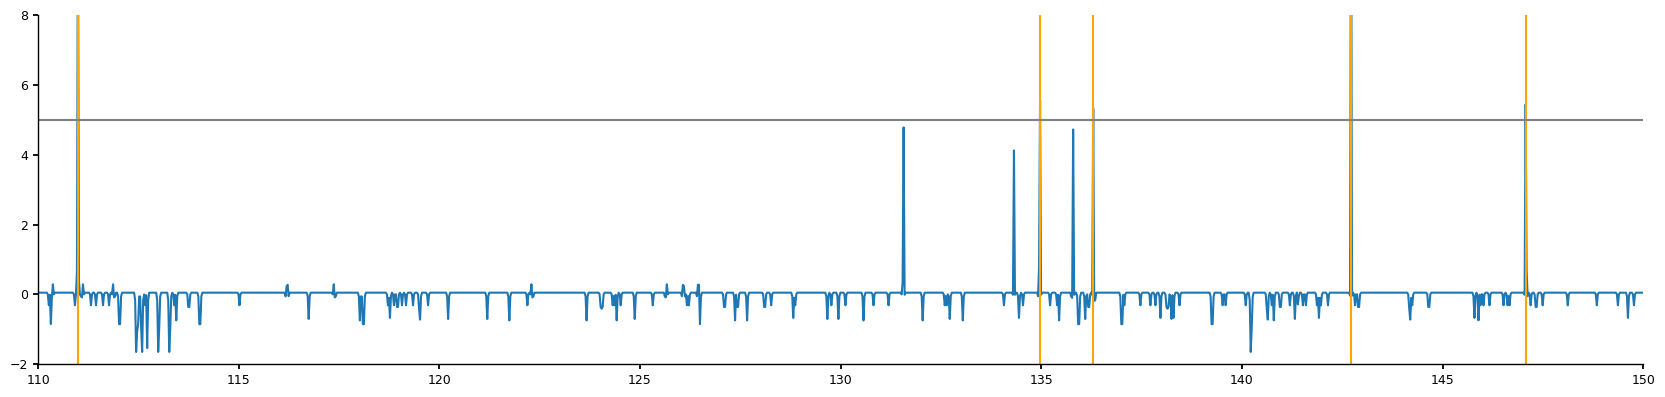

In [5]:
fig, ax = fma.plotting.makeFigure(size=(42,10))
fma.plotting.plotXY(reactivation[:,[0,10]])
fma.plotting.plotRaster(peaks[9][:,0],heigth=20,color='orange')
ax[0].axhline(y=5,color='gray')
ax[0].set(xlim=[110,150],ylim=[-2,8]);

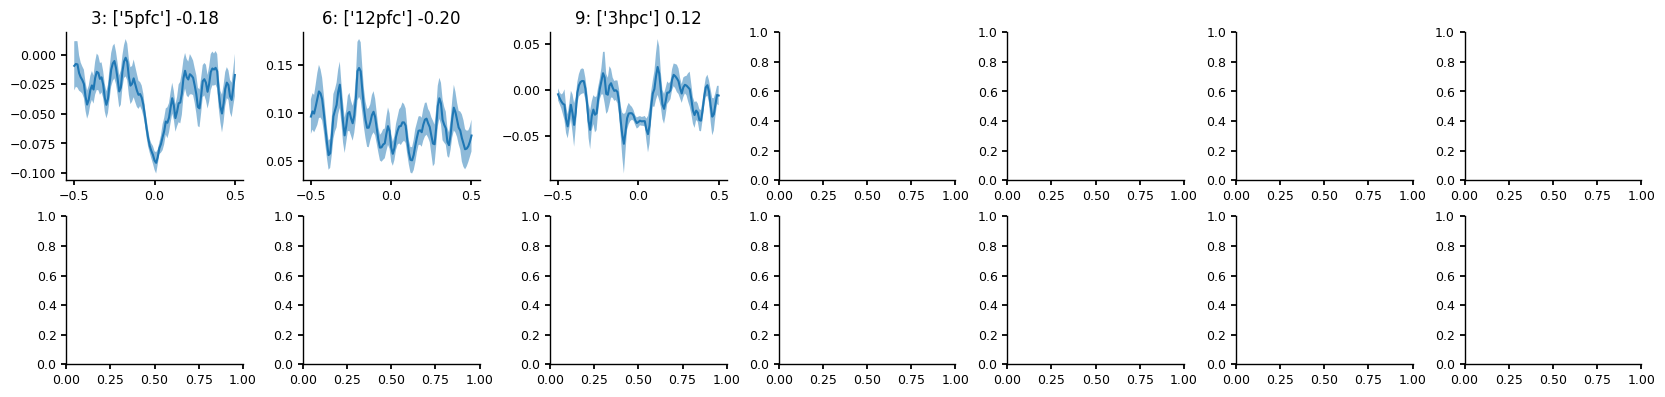

In [15]:
# peth of reactivation around events
name = 'deltaWaves'
n_reg = 1
do_plot = np.where([len(i) == n_reg for i in unique_identities])[0]
fig, ax = fma.plotting.makeFigure(size=(42,10),n=(2,7))
for i, idx in enumerate(do_plot):
    j, k = np.unravel_index(i,(2,5))

    peth, t, _ = fma.analysis.PETH(reactivation[:,[0,idx]],events[name])
    fma.plotting.semPlot(t,peth,ax=ax[j,k])

    ax[j,k].set_title(f'{idx}: {unique_identities[idx]} {t[peth.mean(axis=0).argmax()]:.2f}')

In [148]:
# look for sequential activations
a = 12
lim = np.array([-1,1]) * 0.005 + 0
peth, t, _ = fma.analysis.PETH(spikes[:,0],events[name],groups=spikes[:,1],limits=lim,n_bins=51)
# keep only member neurons
members = np.where(weights[:,a])[0]
peth = peth[:,:,members]
# order of activations in windows
delays = peth.argmax(axis=1) # bin of max activation (event, unit)
delays = delays[np.sum(delays!=0,axis=1)>2,:] # remove events with less than 3 neurons firing

seq = []
for i in range(len(delays)):
    nz = delays[i] != 0
    iden = np.array(identities[a])[nz]
    if len(np.unique(iden)) > 1:
        seq.append(iden[delays[i][nz].argsort()])

In [149]:
for i in range(0,200):
    print(seq[i])

['-hpc' '+nr' '-pfc' '+nr']
['+pfc' '+nr' '+nr' '-hpc']
['-nr' '+pfc' '+nr']
['+hpc' '+nr' '+pfc' '-nr']
['+nr' '+hpc' '+pfc' '+nr' '+hpc']
['+hpc' '-hpc' '+pfc']
['+pfc' '+hpc' '+nr']
['-pfc' '-pfc' '+hpc']
['+nr' '+nr' '-hpc']
['+nr' '+nr' '+hpc' '+pfc']
['+nr' '+pfc' '+hpc']
['+pfc' '-hpc' '-hpc']
['+hpc' '+nr' '+nr' '+nr']
['+nr' '-hpc' '-pfc']
['+hpc' '-pfc' '+nr']
['-pfc' '+hpc' '+nr' '+pfc']
['+nr' '-hpc' '+nr']
['+pfc' '+nr' '+nr']
['+pfc' '+pfc' '-hpc']
['+hpc' '-hpc' '+pfc' '-nr']
['+pfc' '+pfc' '+hpc']
['-hpc' '+nr' '-hpc']
['+pfc' '-pfc' '+nr']
['+nr' '+nr' '+pfc' '-pfc']
['+hpc' '+pfc' '-pfc']
['+nr' '-hpc' '+pfc']
['+nr' '+hpc' '+nr' '+pfc']
['-nr' '+pfc' '+pfc' '+nr']
['-hpc' '+nr' '+hpc']
['+nr' '-hpc' '+nr']
['-hpc' '+pfc' '+nr']
['-pfc' '+pfc' '+nr']
['+nr' '+pfc' '+nr']
['-hpc' '+nr' '-hpc' '+pfc']
['+nr' '-nr' '+nr']
['-hpc' '+pfc' '+nr']
['-hpc' '+hpc' '+nr']
['+hpc' '+nr' '+nr']
['-pfc' '+nr' '+nr' '-nr' '+hpc']
['-pfc' '-nr' '+nr']
['-hpc' '-hpc' '+pfc']
['+nr' '

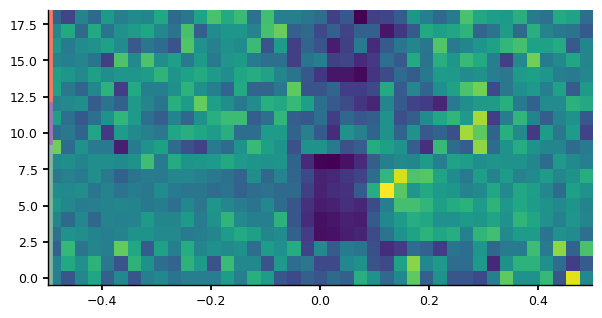

In [56]:
# see how 3-reg assemblies' members activate
a = 9
lim = [-0.5,0.5]
_, t, peth = fma.analysis.PETH(spikes[:,0],events[name],groups=spikes[:,1],limits=lim,n_bins=41)
fig, ax = fma.plotting.makeFigure(size=(15,8))
members = np.where(weights[:,a])[0]
fma.plotting.plotColorMap(peth.T[members],zscore=1,x=t,ax=ax[0])
offset = 0
for r in ['hpc','nr','pfc']:
    reg_members = [i[1:]==r for i in identities[a]]
    ax[0].plot([lim[0],lim[0]],[offset-0.5,offset+sum(reg_members)-0.5],color=isru.paperColors(r),lw=7)
    offset += sum(reg_members)

19
44
53


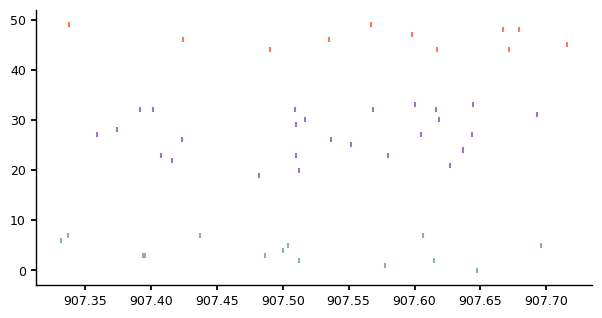

In [35]:
# see how 3-reg assemblies' members activate
a = 12
name = 'ripples'
fig, ax = fma.plotting.makeFigure(size=(15,8))
this_spikes = fma.general.restrict(spikes,events[name][0]+[-0.2,0.2])
members = np.where(weights[:,a])[0]
offset = 0
for r in ['hpc','nr','pfc']:
    reg_members = [i[1:]==r for i in identities[a]]
    fma.plotting.plotRaster(this_spikes,ids=members[reg_members],compact=True,offset=offset,ax=ax[0],color=isru.paperColors(r)); # keep spikes of member neurons
    offset += sum(reg_members)
    print(offset)